In [9]:
from terratorch.datasets.od_augmentation import CopyPasteObjectDetectionDataset
from terratorch.datasets.generic_od_dataset import GenericObjectDetectionDataset
import os
image_dir = os.environ.get("image_dir", "/home/romeokienzler/Downloads/swisstopo/")
object_folder = os.environ.get("object_folder", "/home/romeokienzler/Downloads/objects/")
tile_cache_dir = os.environ.get("tile_cache_dir", "/home/romeokienzler/Downloads/swisstopo_tile_cache/")


In [10]:
dataset = GenericObjectDetectionDataset(
    image_dir=image_dir,
)

sample = dataset[0]
print(sample["image"].shape)
print(sample["boxes"].shape)
print(sample["labels"].shape)
print(sample["boxes"])



torch.Size([3, 10000, 10000])
torch.Size([0, 4])
torch.Size([0])
tensor([], size=(0, 4))


In [12]:
from terratorch.datasets.od_tiled_dataset_wrapper import TiledDataset
tiled_dataset = TiledDataset(
    base_dataset=dataset,
    tile_size=(512, 512),
    overlap=0,
    cache_dir=tile_cache_dir,
    skip_empty_boxes=False
)

Processing items:   0%|          | 0/5 [00:00<?, ?it/s]/home/romeokienzler/gitco/terratorch/terratorch.odaug/.venv/lib64/python3.13/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (100000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Processing items: 100%|██████████| 5/5 [01:38<00:00, 19.63s/it]


In [13]:

dataset_aug = CopyPasteObjectDetectionDataset(
    base_dataset=tiled_dataset,
    object_folder=object_folder,
    scale_range=(0.01, 0.01),
    max_objects=3,
    paste_prob=1
)

sample = dataset_aug[0]
print(sample["image"].shape, sample["mask"].shape)

torch.Size([3, 512, 512]) torch.Size([512, 512])


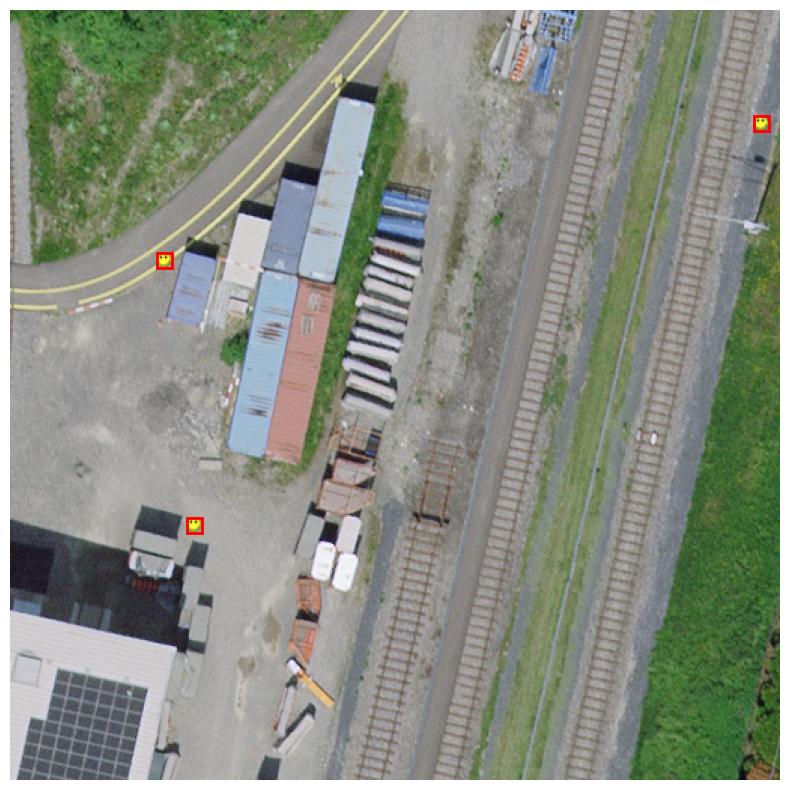

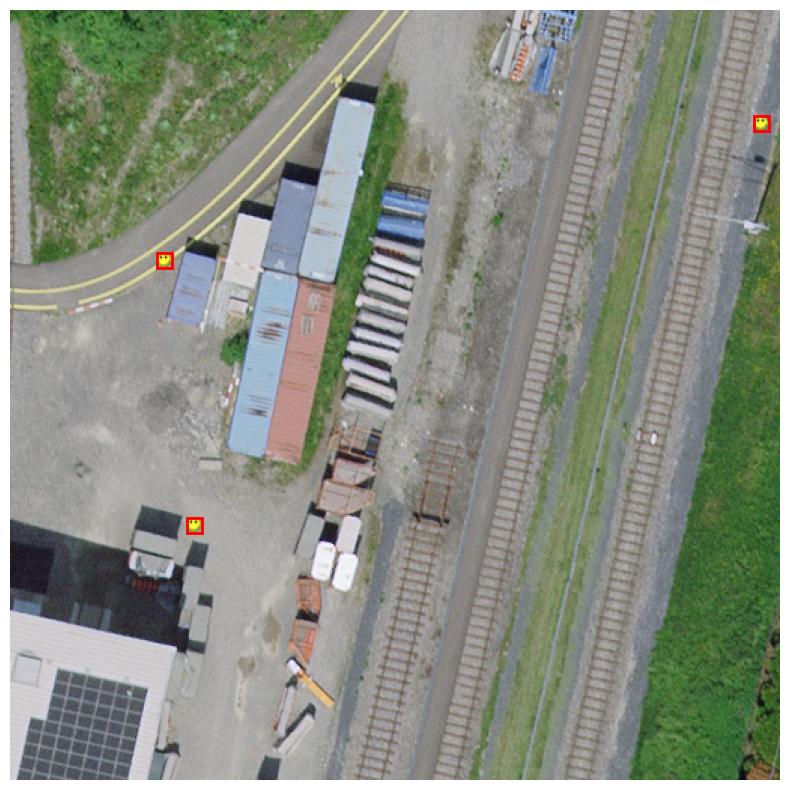

In [14]:
# plot original dataset image with boxes and labels
import terratorch.visualization as ttv
sample_original = dataset[0]
ttv.plot_boxes_labels(sample["image"], sample["boxes"])

In [15]:
from torch.utils.data import DataLoader, random_split
import lightning as L
import torch

class GenericDataModule(L.LightningDataModule):
    def __init__(
        self,
        dataset=None,
        train_dataset=None,
        val_dataset=None,
        test_dataset=None,
        predict_dataset=None,
        split_ratio=(0.6, 0.2, 0.2),
        seed=42,
        batch_size=1,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        collate_fn=None,
        shuffle_train=True,
    ):
        super().__init__()

        self.dataset = dataset
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset
        self.predict_dataset = predict_dataset

        self.split_ratio = split_ratio
        self.seed = seed

        self.batch_size = batch_size
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        self.persistent_workers = persistent_workers
        self.collate_fn = collate_fn
        self.shuffle_train = shuffle_train

        if dataset is None and train_dataset is None:
            raise ValueError(
                "You must provide either `dataset` or `train_dataset`."
            )

    def setup(self, stage=None):
        # already explicitly provided → do nothing
        if self.train_dataset is not None:
            return

        if self.dataset is None:
            raise ValueError("Dataset is None but no explicit splits were provided.")

        n = len(self.dataset)
        r_train, r_val, r_test = self.split_ratio

        if not abs(r_train + r_val + r_test - 1.0) < 1e-6:
            raise ValueError(f"split_ratio must sum to 1, got {self.split_ratio}")

        n_train = int(n * r_train)
        n_val = int(n * r_val)
        n_test = n - n_train - n_val  # remainder → test

        g = torch.Generator().manual_seed(self.seed)

        self.train_dataset, self.val_dataset, self.test_dataset = random_split(
            self.dataset,
            [n_train, n_val, n_test],
            generator=g
        )

    def _loader(self, dataset, shuffle=False):
        if dataset is None:
            return None

        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
            persistent_workers=self.persistent_workers and self.num_workers > 0,
            collate_fn=self.collate_fn,
        )

    def train_dataloader(self):
        return self._loader(self.train_dataset, shuffle=self.shuffle_train)

    def val_dataloader(self):
        return self._loader(self.val_dataset, shuffle=False)

    def test_dataloader(self):
        return self._loader(self.test_dataset, shuffle=False)

    def predict_dataloader(self):
        return self._loader(self.predict_dataset, shuffle=False)


In [37]:
def detection_collate(batch):
    images = torch.stack([b["image"] for b in batch])  # [B, C, H, W]

    targets = {
        "boxes": [b["boxes"] for b in batch],
        "labels": [b["labels"] for b in batch],
    }

    return {
        "image": images,
        **targets,
    }



dm = GenericDataModule(
    dataset=dataset_aug,
    batch_size=4,
    num_workers=4,
    collate_fn=detection_collate
)

In [41]:
dm.setup("fit")

In [42]:
train_loader = dm.train_dataloader()
batch = next(iter(train_loader))

/home/romeokienzler/gitco/terratorch/terratorch.odaug/.venv/lib64/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [43]:
len(batch['image'])

4

In [44]:
from terratorch.tasks import ObjectDetectionTask
from terratorch.models.object_detection_model_factory import ObjectDetectionModelFactory

model = ObjectDetectionTask(
    model_factory="ObjectDetectionModelFactory",
    model_args={
        "framework": "faster-rcnn",
        "backbone": "terramind_v1_tiny",
        "backbone_pretrained": True,
        "num_classes": 2,
        "framework_min_size": 512,
        "framework_max_size": 512,
        "backbone_modalities": ["RGB"],
        "in_channels": 3,
        "necks": [
            {
                "name": "SelectIndices",
                "indices": [2, 5, 8, 11],
            },
            {
                "name": "ReshapeTokensToImage",
                "remove_cls_token": False,
            },
            {
                "name": "LearnedInterpolateToPyramidal",
            },
            {
                "name": "FeaturePyramidNetworkNeck",
            },
        ],
    },
    freeze_backbone=False,
    freeze_decoder=False,
    class_names=[
        "Background",
        "SimpleObject",
    ],
)


/home/romeokienzler/gitco/terratorch/terratorch.odaug/terratorch/tasks/object_detection_task.py:96: UserWarning: The Object Detection Task has to be considered experimental. This is less mature than the other tasks and being further improved.
  warnings.warn("The Object Detection Task has to be considered experimental. This is less mature than the other tasks and being further improved.")


In [ ]:
trainer = L.Trainer(max_epochs=5, accelerator="auto")
trainer.fit(model, dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name          | Type                 | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0 | model         | ObjectDetectionModel | 22.6 M | train | 0    
1 | train_metrics | MetricCollection     | 0      | train | 0    
2 | val_metrics   | MetricCollection     | 0      | train | 0    
3 | test_metrics  | MetricCollection     | 0      | train | 0    
-----------------------------------------------------------------------
22.6 M    Trainable params
0         Non-trainable params
22.6 M    Total params
90.577    Total estimated model params size (MB)
237       Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 0:   2%|▏         | 6/271 [01:41<1:14:26,  0.06it/s, v_num=2]        